# ch232 — Fourier Series

**Advanced Calculus Experiment 2.**

Any periodic function can be decomposed into an infinite sum of sines and cosines. This is the Fourier series. It is one of the most powerful ideas in applied mathematics — signal processing, audio compression, solving PDEs, and even neural network theory all rest on it.

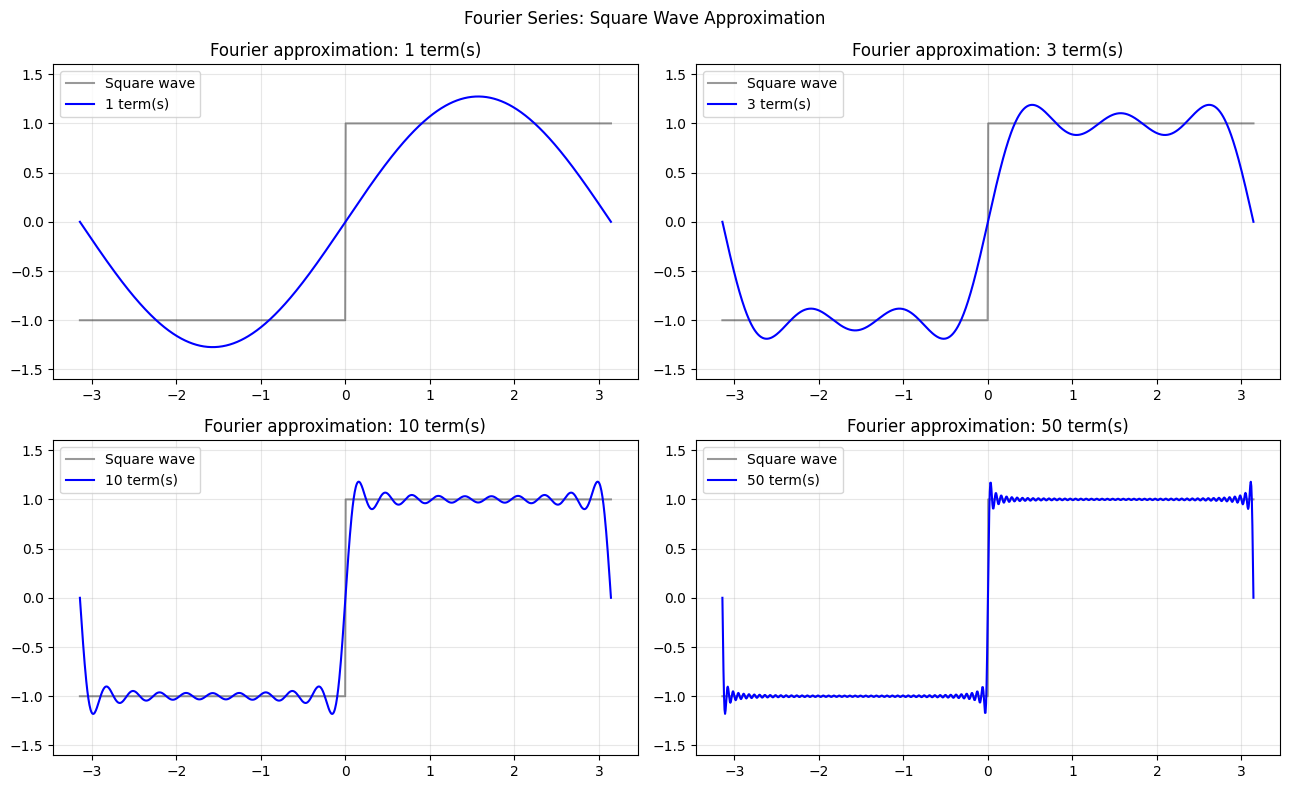

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fourier series of a square wave
# f(x) = (4/pi) * sum_{k=0}^{inf} sin((2k+1)x) / (2k+1)

x = np.linspace(-np.pi, np.pi, 1000)

def square_wave(x): return np.sign(np.sin(x))

def fourier_approx(x, n_terms):
    result = np.zeros_like(x, dtype=float)
    for k in range(n_terms):
        result += np.sin((2*k+1)*x) / (2*k+1)
    return 4/np.pi * result

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
exact = square_wave(x)
for ax, n in zip(axes.flat, [1, 3, 10, 50]):
    ax.plot(x, exact, 'k', lw=1.5, alpha=0.4, label='Square wave')
    ax.plot(x, fourier_approx(x, n), 'b', lw=1.5, label=f'{n} term(s)')
    ax.set_ylim(-1.6, 1.6); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_title(f'Fourier approximation: {n} term(s)')
plt.suptitle('Fourier Series: Square Wave Approximation', fontsize=12)
plt.tight_layout(); plt.savefig('ch232_fourier_series.png', dpi=100); plt.show()


## Fourier Coefficients

For a function f(x) with period 2pi, the Fourier coefficients are inner products:

```
a_k = (1/pi) * integral f(x) cos(kx) dx
b_k = (1/pi) * integral f(x) sin(kx) dx
```

Computing these numerically via the Discrete Fourier Transform (DFT) is the key operation in audio, image, and signal processing.

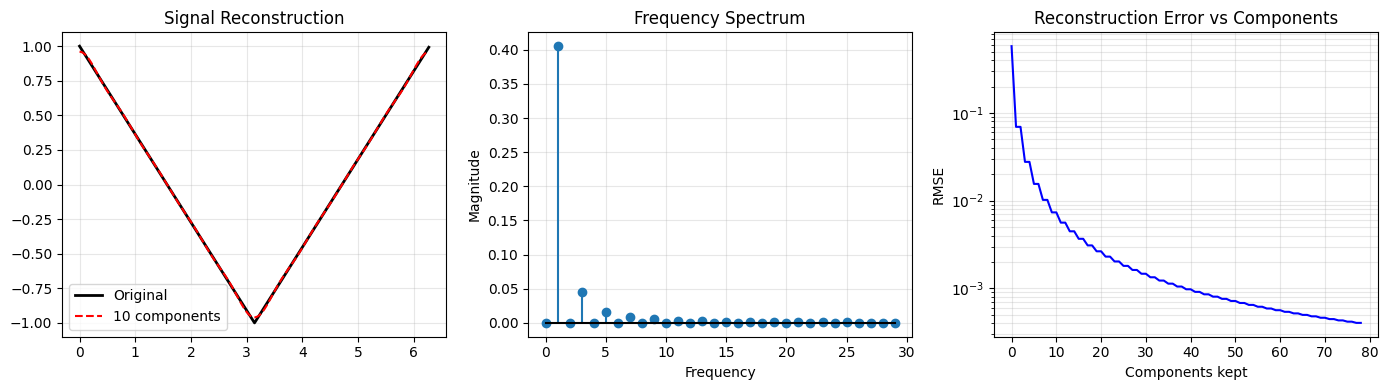

In [2]:
# Compute Fourier coefficients numerically and reconstruct
# Signal: triangular wave
N = 512
t = np.linspace(0, 2*np.pi, N, endpoint=False)
signal = 2*np.abs(t/np.pi - 1) - 1   # triangular wave in [-1,1]

# DFT (numpy's FFT)
freq_domain = np.fft.rfft(signal)
magnitudes = np.abs(freq_domain) / N

freqs = np.fft.rfftfreq(N, d=1/N)

# Reconstruct from only first 10 Fourier components
freq_truncated = np.zeros_like(freq_domain)
freq_truncated[:10] = freq_domain[:10]
reconstructed = np.fft.irfft(freq_truncated, n=N)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(t, signal, 'k', lw=2, label='Original')
axes[0].plot(t, reconstructed, 'r--', lw=1.5, label='10 components')
axes[0].legend(); axes[0].set_title('Signal Reconstruction'); axes[0].grid(True, alpha=0.3)

axes[1].stem(freqs[:30], magnitudes[:30], markerfmt='C0o', linefmt='C0-', basefmt='k-')
axes[1].set_xlabel('Frequency'); axes[1].set_ylabel('Magnitude')
axes[1].set_title('Frequency Spectrum'); axes[1].grid(True, alpha=0.3)

# Reconstruction error vs number of components
errs = []
for k in range(1, 80):
    ft = np.zeros_like(freq_domain); ft[:k] = freq_domain[:k]
    rec = np.fft.irfft(ft, n=N)
    errs.append(np.sqrt(np.mean((rec - signal)**2)))
axes[2].semilogy(errs, 'b-'); axes[2].set_xlabel('Components kept')
axes[2].set_ylabel('RMSE'); axes[2].set_title('Reconstruction Error vs Components')
axes[2].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch232_fft.png', dpi=100); plt.show()


## Summary

| Concept | Key Idea |
|---|---|
| Fourier series | Decompose periodic f into sin/cos components |
| Fourier coefficients | Inner products with basis functions |
| DFT / FFT | Discrete version; O(N log N) algorithm |
| Gibbs phenomenon | Ringing near discontinuities — never fully disappears |

**Forward reference:** ch298 — Information Theory (Part IX) builds on frequency-domain ideas to define entropy and information content.